# DEMO CLASSIFICADOR

Aquesta _Jupyter Notebook_  serveix per mostrar de manera còmoda el funcionament de l'algorisme dels models de detecció.

## IMPORTS

In [13]:
import os
import pandas as pd
import numpy as np
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier

## PREPARACIÓ DEL DATASET

In [14]:
# Carreguem les dades
df1 = pd.read_csv('df_hp_adni.csv', sep=',')
df1 = df1[['subject','age', 'abeta_pos']]
df2 = pd.read_csv('supersynth_vols.csv', sep=',')
df2["total intracranial"] = df2.select_dtypes(include="number").sum(axis=1) # aconseguim el total intracranial
df2.drop(columns =['session','Unnamed: 0'],inplace=True)

# Unir dataframes
df_total = pd.merge(df1, df2, on= 'subject')

# Scikit-learn no accepta NaNs, també els eliminem
df_total = df_total.dropna()

# Mides del dataset "original"
print(f'El dataset original és de {df_total.shape}')

# Encoding de la variable objectiu (negatiu = 0, positiu = 1)
le = LabelEncoder()
y = le.fit_transform(df_total['abeta_pos'])

# Variables predictores
X = df_total.drop(columns=['subject'])

El dataset original és de (696, 45)


## PRIMERA NORMALITZACIÓ DE LES DADES

In [15]:
dividir_total = True # Una variable per decidir si dividim pel volum total intracranial o no
if dividir_total:
    # Comencem la normalització dividint pel volum intracranial
    # Fem una llista amb les columnes que hem de normalitzar (excloem total intracranial, PTAGE i SCORE que no s'han de normalitzar)
    cols_to_normalize = X.columns.drop(['total intracranial', 'age', 'abeta_pos'])

    # Dividim les columnes per la referència (total intracranial)
    X[cols_to_normalize] = X[cols_to_normalize].div(X['total intracranial'], axis=0)

# El següent pas per normalitzar és: fer un model de regressió lineal que predigui el volum amb l'edat
# Omplir els valors del df amb valor_real - valor_predit
# Fer-ho només amb els pacients que siguin negatius
# fit_intercept = True, evita que el model de regressió hagi de començar pel 0 de l'eix vertical

# Només entrenarem amb els pacients sans (SCORE = negative)
X_negativos = X[X['abeta_pos'] == False]

# El mateix d'abans, definim quines columnes s'han de normalitzar
cols_to_correct = X.columns.drop(['age', 'total intracranial', 'abeta_pos'])

# Bucle per ajustar el model per cada columna
for col in cols_to_correct:
    model = LinearRegression(fit_intercept=True)

    # Entrenem només amb els negatius
    X_train = X_negativos[['age']]
    y_train = X_negativos[col]

    model.fit(X_train, y_train)

    # Predim per TOT el dataset complet (positius i negatius)
    # Volem saber el volum esperat per la seva edat
    valores_predichos = model.predict(X[['age']])

    # Calculem el residu: Valor Real - Valor Predit
    # Sobreescrivim amb el valor predit la columna
    X[col] = X[col] - valores_predichos

Podem mirar l'aspecte de la nostra variable X

In [16]:
X.head()

,age,abeta_pos,3rd-Ventricle (14),4th-Ventricle (15),Brain-Stem (16),WM-hypointensities (77),Optic-Chiasm (85),Left-Cerebral-White-Matter (2),Left-Cerebral-Cortex (3),Left-Lateral-Ventricle (4),...,Right-Pallidum (52),Right-Hippocampus (53),Right-Amygdala (54),Right-Accumbens-area (58),Right-HypoThal-noMB (820),Right-Fornix (822),Right-MammillaryBody (844),Right-Basal-Forebrain (866),Right-SeptalNuc (870),total intracranial
0,81.4,True,0.000122,-0.000009,0.004450,0.000066,0.000012,-0.008139,-0.011973,0.006601,...,0.000188,-0.000508,-0.000400,-0.000022,-0.000027,0.000087,0.000002,1.316726e-05,1.663188e-05,8.613182e+05
1,79.2,True,0.000918,-0.000068,0.001085,0.001086,0.000019,-0.010003,-0.003937,0.012118,...,-0.000051,-0.000157,-0.000283,-0.000099,-0.000003,0.000045,0.000008,4.552492e-06,1.892389e-06,1.065463e+06
2,73.6,True,0.000462,0.000393,-0.001586,0.002820,-0.000021,-0.001935,-0.006788,0.014276,...,-0.000072,-0.000362,-0.000101,-0.000017,-0.000020,0.000025,0.000008,9.702219e-07,3.717373e-06,1.133442e+06
3,73.5,True,-0.000296,-0.000350,-0.000597,-0.002480,-0.000012,0.008943,-0.003562,0.001772,...,-0.000131,0.000209,-0.000024,0.000004,-0.000016,-0.000031,-0.000012,9.543852e-07,8.952962e-07,1.030656e+06
4,82.7,True,0.000115,-0.000200,0.000704,0.003259,0.000020,-0.001049,-0.006826,0.008187,...,0.000006,-0.000108,-0.000155,-0.000060,0.000026,-0.000049,0.000005,3.171630e-05,9.307287e-06,1.104136e+06


## ÚLTIMS PASSOS PER A TENIR EL DATASET LLEST

In [17]:
# La meva variable predictora ja neta
X.drop(columns=['total intracranial', 'age', 'abeta_pos'], inplace=True)

# --- EL FIX PER L' ERROR DE 'c_contiguous' ---
# Convertim X en un array de numpy pur i ens assegurem de que sigui C-contiguous
X = np.ascontiguousarray(X.values)
# -----------------------------------------------

# Pot ser que hi hagi algun total intracranial que sigui 0
# Retorna True si hi ha al menys un NaN
hay_nan = np.isnan(X).any()

if hay_nan:
    # Crear una màscara de las files que NO tenen NaN
    mask = ~np.isnan(X).any(axis=1)

    # Filtrar els arrays amb la mateixa màscara (Tornem a eliminar NaN que hagin aparegut en aquest preprocés)
    X = X[mask]
    y = y[mask]

# Mirem la mida del dataset al final
print(f'El dataset que utilitzem finalment és de {X.shape}')

El dataset que utilitzem finalment és de (696, 41)


## PREPARACIÓ DE L'ENTRENAMENT I MODELS

In [18]:
# Llibreries extres
from sklearn.model_selection import StratifiedKFold  # Per entrenar fent folds
from sklearn.utils import \
    resample  # Per aconseguir que a cada fold hi hagi el mateix nombre de positius que de negatius

# Definim l'objecte de validació creuada
# n_splits=5 significa que entrenarem 5 vegades (80% tren / 20% test cada vegada)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Llistes per guardar els resultados de cada "fold"
resultados_acc = []
resultados_sens = []
resultados_espec = []
resultados_prec = []

print(f"Iniciant validació creuada amb {skf.get_n_splits()} folds...\n")

# Aquí preparem l'ensamble
# Models
clf1 = svm.SVC(kernel='rbf', probability=True, class_weight='balanced',random_state=42)  # Lo de probaility = True és pel voting soft
clf2 = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
clf3 = KNeighborsClassifier(n_neighbors=5, weights='distance')
logreg = LogisticRegression(random_state=16, max_iter=5000, class_weight='balanced')
gradboost = HistGradientBoostingClassifier(class_weight='balanced',random_state=42)
# Xarxa neuronal petita
# (10, 8) significa 10 neurones en la 1ª capa i 8 en la 2ª.
mlp_clf = MLPClassifier(
    hidden_layer_sizes=(10, 8),
    max_iter=1000,
    early_stopping=True,  # Per no sobreentrenar
    validation_fraction=0.1,  # Proporció de les dades d'entrenament que s'utilitzen com a validació
    random_state=42,
    activation='relu'  # Funció d'activació estàndard
)

# Ensamble
modelos = [('svm', clf1), ('rf', clf2), ('knn', clf3), ('gradboost', gradboost), ('logreg', logreg), ('mlp', mlp_clf)]
ensemble = VotingClassifier(estimators=modelos, voting='soft')

Iniciant validació creuada amb 5 folds...



## EL BUCLE D'ENTRENAMENT

Fold 1: Entrenat amb 336 pacients (168 de cada). Acc: 0.7571
Fold 2: Entrenat amb 338 pacients (169 de cada). Acc: 0.6906
Fold 3: Entrenat amb 338 pacients (169 de cada). Acc: 0.7122
Fold 4: Entrenat amb 338 pacients (169 de cada). Acc: 0.6619
Fold 5: Entrenat amb 338 pacients (169 de cada). Acc: 0.6978


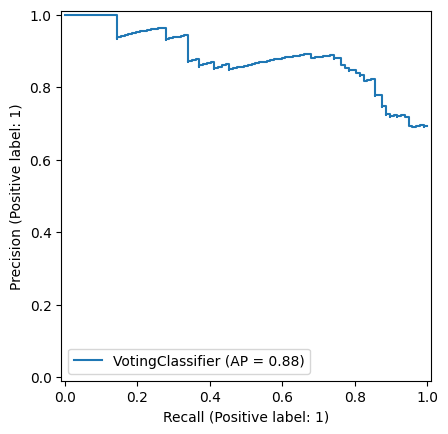

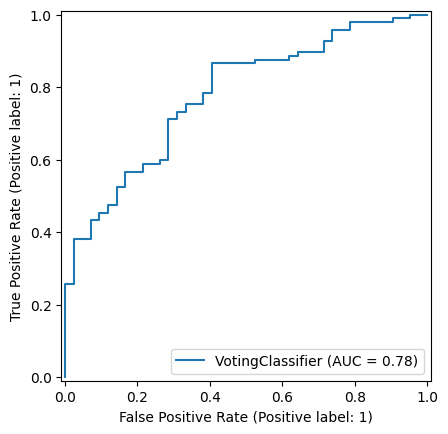

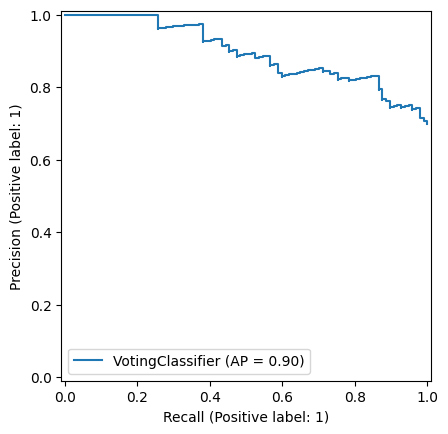

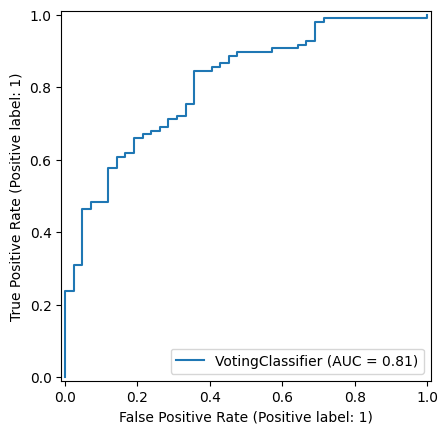

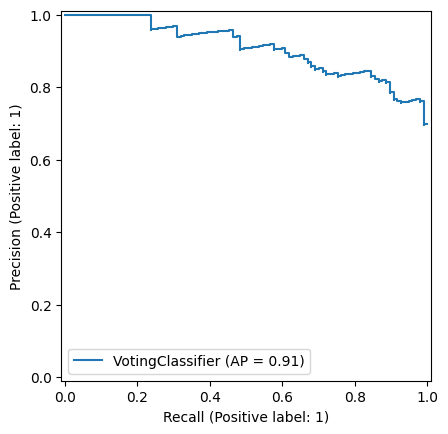

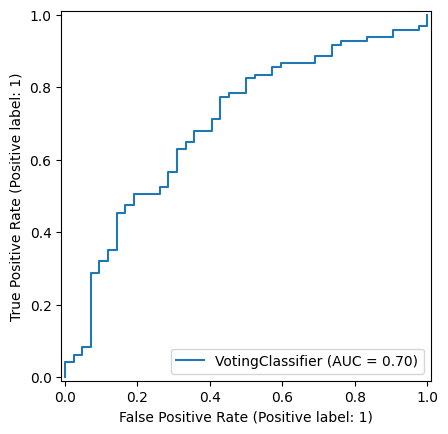

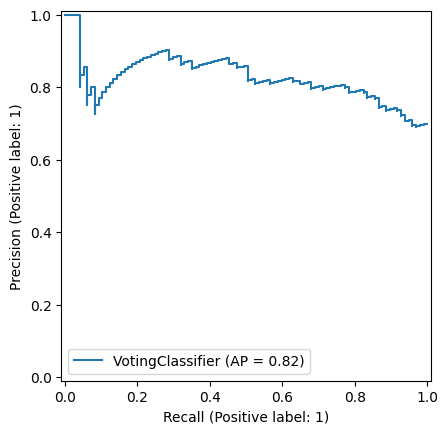

<Figure size 640x480 with 0 Axes>

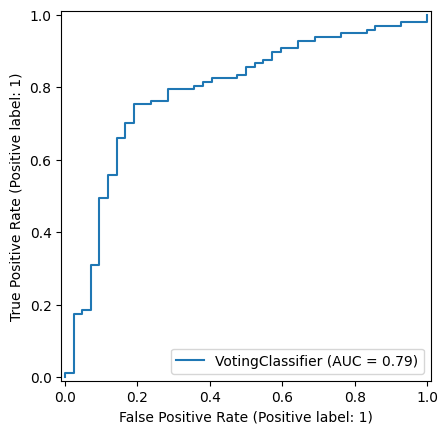

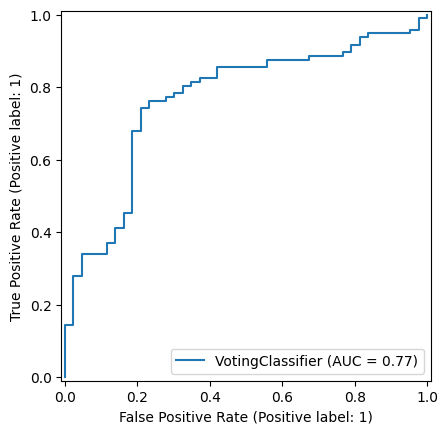

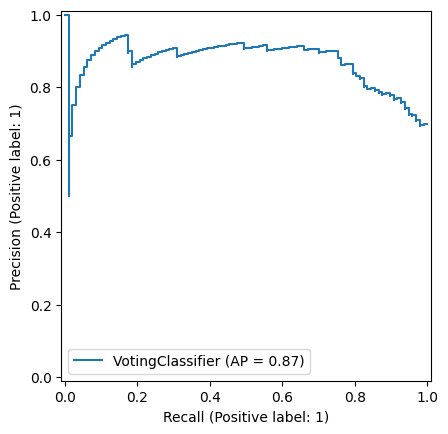

In [19]:
# skf.split(X, y) genera els índexs para cada ronda
for i, (train_index, test_index) in enumerate(skf.split(X, y)):

    # Separem les dades d'aquesta ronda
    X_train_fold, X_test_fold = X[train_index], X[test_index]
    y_train_fold, y_test_fold = y[train_index], y[test_index]

    # --- BALANCEIG MANUAL DINS L'ENTRENAMENT ---
    # Separem per classes dins el set d'entrenament
    X_pos = X_train_fold[y_train_fold == 1]
    X_neg = X_train_fold[y_train_fold == 0]

    # El nombre de mostres serà el nombre més petit entre els pacients que tenim positius i els que tenim negatius
    n_muestras = min(len(X_pos), len(X_neg))  # També pot ser un número fix si això no ens convenç

    # Mostregem els dos grups perquè tinguin el mateix nombre de dades
    X_pos_res = resample(X_pos, n_samples=n_muestras, replace=False, random_state=42)
    X_neg_res = resample(X_neg, n_samples=n_muestras, replace=False, random_state=42)

    # Creem el set d'entrenament final d'aquesta ronda
    X_train_balanced = np.vstack((X_pos_res, X_neg_res))
    y_train_balanced = np.array([1] * n_muestras + [0] * n_muestras)

    # --- NORMALIITZACIÓ ---
    # Només entrenem el normalitzador amb els que siguin negatius !!
    scaler = StandardScaler()
    mask_sanos = (y_train_balanced == 0)
    scaler.fit(X_train_balanced[mask_sanos])

    X_train_ready = scaler.transform(X_train_balanced)
    X_test_ready = scaler.transform(X_test_fold)

    # --- ENTRENAMENT ---
    ensemble.fit(X_train_ready, y_train_balanced)

    # --- EVALUACIÓ ---
    preds = ensemble.predict(X_test_ready)
    cm_fold = confusion_matrix(y_test_fold, preds)
    tn, fp, fn, tp = cm_fold.ravel()

    # Càlcul de mètriques
    acc = accuracy_score(y_test_fold, preds)
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    espec = tn / (tn + fp) if (tn + fp) > 0 else 0
    prec = precision_score(y_test_fold, preds)

    # Ho guardem als vectors d'abans
    resultados_acc.append(acc)
    resultados_sens.append(sens)
    resultados_espec.append(espec)
    resultados_prec.append(prec)

    print(f"Fold {i + 1}: Entrenat amb {n_muestras * 2} pacients ({n_muestras} de cada). Acc: {acc:.4f}")

    # -- GUARDEM IMATGES
    # Creem una carpeta on guardar les figures
    if not os.path.isdir('figures_balanced'):
        os.mkdir('figures_balanced')

    # La corba ROC
    plt.figure(0)
    RocCurveDisplay.from_estimator(ensemble, X_test_ready, y_test_fold)
    plt.savefig(f'figures_balanced/roc_fold {i + 1}.svg')

    # La precision-recall curve
    plt.figure(1)
    PrecisionRecallDisplay.from_estimator(ensemble, X_test_ready, y_test_fold)
    plt.savefig(f'figures_balanced/precision_recall_fold {i + 1}.svg')
    # --


## RESULTATS FINALS

In [20]:
print("\n" + "=" * 30)
print("   RESUM FINAL DEL MODEL")
print("=" * 30)
print(f"Accuracy Mitjana:      {np.mean(resultados_acc):.4f}")
print(f"Sensibilitat Mitjana:  {np.mean(resultados_sens):.4f} (Capacitat detecció positius)")
print(f"Especificitat Mitjana: {np.mean(resultados_espec):.4f} (Capacitat detecció negatius)")
print(f"Precisió Mitjana: {np.mean(resultados_prec):.4f} (Capacitat per no etiquetar com a positiu un valor negatiu)")
print("=" * 30)


   RESUM FINAL DEL MODEL
Accuracy Mitjana:      0.7039
Sensibilitat Mitjana:  0.6866 (Capacitat detecció positius)
Especificitat Mitjana: 0.7439 (Capacitat detecció negatius)
Precisió Mitjana: 0.8620 (Capacitat per no etiquetar com a positiu un valor negatiu)


## ESTALVI

In [21]:
# Aquest apartat busca mirar l'estalvi que es guanyaria en utilitzar el model
# Fòrmules extretes de "Study of early stages of Alzheimer’s disease using magnetic resonance imaging" d'Adrià Casamitjana

ro = 0.2  # prevalença esperada de pacients amyloid positius en la població general
Cpet = 3000  # preu en euros d'un PET
Cmri = 700  # preu en euros d'un MRI
Ns = df_total.shape[0]  # Nombre de pacients que vull observar, els del meu estudi

Cs = Ns * (Cpet + Cmri)  # Cost de l'estudi si no comptéssim amb el model

K = Ns * ro  # Nombre ideal de pacients que volem reclutar (idealment serien els que el model ha marcat com True Positive)
R = np.mean(resultados_sens)  # Sensibilitat
P = np.mean(resultados_prec)  # Precisió

Cp = K / ro * (Cmri / R + ro * Cpet / P)  # Cost de l'estudi amb el model

estalvi = ((Cs - Cp) / Cs) * 100  # Percentatge d'estalvi

# print(Ns)
print("\n" + "=" * 30)
print("   SAVINGS DEL MODEL")
print("=" * 30)
print(f"Sense el model l'estudi costaria: {Cs:.4f}")
print(f"Amb el model l'estudi costaria: {Cp:.4f}")
print(f"Hem estalviat un: {estalvi:.4f}")
print("=" * 30)


   SAVINGS DEL MODEL
Sense el model l'estudi costaria: 2575200.0000
Amb el model l'estudi costaria: 1194058.0631
Hem estalviat un: 53.6324
